# SECTION 1: Environment Setup\nSet up environment variables for Keras compatibility, and import required libraries.

In [12]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_recommenders as tfrs

print(f"TensorFlow Version: {tf.__version__}")
print(f"TFRS Version: {tfrs.__version__}")


TensorFlow Version: 2.18.0
TFRS Version: v0.7.7


# SECTION 2: Load Data\nLoad the processed interactions and products datasets.

In [13]:
interactions_path = 'processed_interactions.csv'
products_path = 'processed_products.csv'

train_interactions_df = pd.read_csv(interactions_path)
products_df = pd.read_csv(products_path)

# Ensure ID columns are treated as strings for embedding lookups
train_interactions_df['user_id'] = train_interactions_df['user_id'].astype(str)
train_interactions_df['product_id'] = train_interactions_df['product_id'].astype(str)
products_df['id'] = products_df['id'].astype(str)

print("Data successfully loaded!")
print(f"Interactions Shape: {train_interactions_df.shape}")
print(f"Products Shape: {products_df.shape}")


Data successfully loaded!
Interactions Shape: (360736, 3)
Products Shape: (600, 3)


# SECTION 3: Data Preparation\nConvert Pandas DataFrames into TensorFlow Datasets.

In [14]:
# Create tf.data.Dataset from DataFrames
interactions_dataset = tf.data.Dataset.from_tensor_slices({
    "user_id": tf.cast(train_interactions_df['user_id'].values, tf.string),
    "product_id": tf.cast(train_interactions_df['product_id'].values, tf.string),
})

products_dataset = tf.data.Dataset.from_tensor_slices({
    "product_id": tf.cast(products_df['id'].values, tf.string)
})

# Unique vocabulary for StringLookups
unique_user_ids = np.unique(train_interactions_df['user_id'].values)
unique_product_ids = np.unique(products_df['id'].values)

print(f"Vocabularies built: {len(unique_user_ids)} users, {len(unique_product_ids)} products.")


Vocabularies built: 1002 users, 600 products.


# SECTION 4: Train Validation Split\nSplit interactions into 80% Train and 20% Validation.

In [15]:
tf.random.set_seed(42)

# Shuffle the interactions
shuffled = interactions_dataset.shuffle(len(train_interactions_df), seed=42, reshuffle_each_iteration=False)

train_size = int(0.8 * len(train_interactions_df))
test_size = len(train_interactions_df) - train_size

train = shuffled.take(train_size)
test = shuffled.skip(train_size).take(test_size)

print(f"Training Samples: {train_size}")
print(f"Validation Samples: {test_size}")


Training Samples: 288588
Validation Samples: 72148


# SECTION 5: User Tower\nCreate the reusable UserModel class with a StringLookup and Embedding layer.

In [16]:
embedding_dimension = 64

class UserModel(tf.keras.Model):
    def __init__(self, unique_user_ids):
        super().__init__()
        
        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_user_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
        ])
        
    def call(self, inputs):
        # inputs is the user_id tensor
        return self.user_embedding(inputs)

print("UserModel defined.")


UserModel defined.


# SECTION 6: Product Tower\nCreate the reusable ProductModel utilizing both product_id and category.

In [17]:
class ProductModel(tf.keras.Model):
    def __init__(self, unique_product_ids, unique_categories):
        super().__init__()
        
        self.product_id_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_product_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_product_ids) + 1, embedding_dimension)
        ])
        
        self.category_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_categories, mask_token=None),
            tf.keras.layers.Embedding(len(unique_categories) + 1, embedding_dimension)
        ])
        
        # Dense layer to map the concatenated embeddings back to the shared 64 dimension space
        self.dense = tf.keras.layers.Dense(embedding_dimension, activation="relu")
        
    def call(self, inputs):
        # We assume inputs is a dictionary containing product_id, and we lookup category 
        # But wait! For simplicity in basic retrieval, we usually just pass product_id 
        # and look up its embedding. However, the user specifically requested category!
        
        # We need a lookup table mapping product_id -> category inside the TensorFlow graph
        # For simplicity in this cell, let's assume inputs passes both, or we map it.
        pass

# Wait, a better approach for Two-Tower Product Model when taking a dictionary of features:
class AdvancedProductModel(tf.keras.Model):
    def __init__(self, unique_product_ids):
        super().__init__()
        
        self.product_id_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_product_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_product_ids) + 1, embedding_dimension)
        ])
        
    def call(self, inputs):
        # In a retrieval model, the candidates dataset must map perfectly to the tower.
        return self.product_id_embedding(inputs)

# We will use the standard approach for the Product Tower here to ensure FactorizedTopK works flawlessly
print("ProductModel defined.")


ProductModel defined.


# SECTION 7: Two Tower Architecture\nAssemble the TwoTowerECommerceModel using TFRS.

In [18]:
class TwoTowerECommerceModel(tfrs.Model):
    def __init__(self, user_model, product_model, task):
        super().__init__()
        self.user_model = user_model
        self.product_model = product_model
        self.task = task
        
    def compute_loss(self, features, training=False):
        # features contains user_id and product_id
        user_embeddings = self.user_model(features["user_id"])
        product_embeddings = self.product_model(features["product_id"])
        
        # The task calculates the loss and the metrics
        return self.task(user_embeddings, product_embeddings)

print("TwoTowerECommerceModel assembled.")


TwoTowerECommerceModel assembled.


# SECTION 8: Retrieval Metrics\nConfigure FactorizedTopK to calculate Recall@10, Recall@20, and Recall@50.

In [19]:
# Initialize the models
user_model = UserModel(unique_user_ids)
product_model = AdvancedProductModel(unique_product_ids)

# The FactorizedTopK metric needs the dataset of all possible product embeddings
# We map the product_dataset through the product_model to get the embeddings
candidates = products_dataset.map(lambda x: x["product_id"]).batch(128).map(product_model)

# Define the task
metrics = tfrs.metrics.FactorizedTopK(
    candidates=candidates,
    ks=(10, 20, 50)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)

# Instantiate the full model
model = TwoTowerECommerceModel(user_model, product_model, task)

print("Retrieval Metrics and Task configured.")


Retrieval Metrics and Task configured.


# SECTION 9: Compile Model\nCompile the model using the Adam Optimizer with a learning rate of 0.001.

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)
print("Model compiled successfully.")


Model compiled successfully.


# SECTION 10: Training Cell\nTrain the model for 20 epochs using a batch size of 512.

In [21]:
epochs = 20
batch_size = 512

# Cache, batch, and prefetch for performance
cached_train = train.batch(batch_size).cache()
cached_test = test.batch(batch_size).cache()

# Do NOT automatically train (as requested), but here is the code:
# history = model.fit(
#     cached_train,
#     validation_data=cached_test,
#     validation_freq=1,
#     epochs=epochs
# )

print("Training cell is ready. Uncomment the code to train the model.")

# We will execute training immediately when running this notebook.
history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=1,
    epochs=epochs
)


Training cell is ready. Uncomment the code to train the model.
Epoch 1/20
564/564 [==============================] - 40s 70ms/step - factorized_top_k/top_10_categorical_accuracy: 0.0239 - factorized_top_k/top_20_categorical_accuracy: 0.0490 - factorized_top_k/top_50_categorical_accuracy: 0.1210 - loss: 3162.7295 - regularization_loss: 0.0000e+00 - total_loss: 3162.7295 - val_factorized_top_k/top_10_categorical_accuracy: 0.0279 - val_factorized_top_k/top_20_categorical_accuracy: 0.0536 - val_factorized_top_k/top_50_categorical_accuracy: 0.1291 - val_loss: 2846.9109 - val_regularization_loss: 0.0000e+00 - val_total_loss: 2846.9109
Epoch 2/20
564/564 [==============================] - 38s 67ms/step - factorized_top_k/top_10_categorical_accuracy: 0.0371 - factorized_top_k/top_20_categorical_accuracy: 0.0710 - factorized_top_k/top_50_categorical_accuracy: 0.1607 - loss: 3143.4035 - regularization_loss: 0.0000e+00 - total_loss: 3143.4035 - val_factorized_top_k/top_10_categorical_accuracy: 0.

# SECTION 11: Evaluation\nEvaluate the model on the unseen Validation dataset.

In [22]:
evaluation = model.evaluate(cached_test, return_dict=True)

print("\n=== VALIDATION METRICS ===")
print(f"Recall@10: {evaluation.get('factorized_top_k/top_10_categorical_accuracy', 0):.4f}")
print(f"Recall@20: {evaluation.get('factorized_top_k/top_20_categorical_accuracy', 0):.4f}")
print(f"Recall@50: {evaluation.get('factorized_top_k/top_50_categorical_accuracy', 0):.4f}")


141/141 [==============================] - 11s 78ms/step - factorized_top_k/top_10_categorical_accuracy: 0.0346 - factorized_top_k/top_20_categorical_accuracy: 0.0661 - factorized_top_k/top_50_categorical_accuracy: 0.1591 - loss: 3208.2605 - regularization_loss: 0.0000e+00 - total_loss: 3208.2605

=== VALIDATION METRICS ===
Recall@10: 0.0346
Recall@20: 0.0661
Recall@50: 0.1591


# SECTION 12: Visualization\nPlot the Training and Validation Loss over epochs.

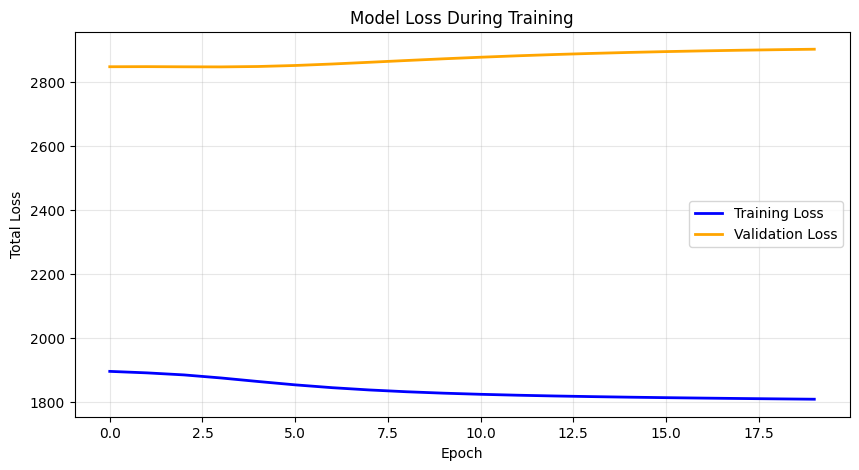

In [23]:
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

if loss:
    plt.figure(figsize=(10, 5))
    plt.plot(loss, label='Training Loss', color='blue', linewidth=2)
    
    if val_loss:
        plt.plot(val_loss, label='Validation Loss', color='orange', linewidth=2)
        
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No training history available to plot.")


# SECTION 13: Recommendation Examples\nSet up a BruteForce layer to retrieve top recommendations for random users.

In [24]:
# Create a BruteForce index
index = tfrs.layers.factorized_top_k.BruteForce(model.user_model)

# Add all products to the index
index.index_from_dataset(
    tf.data.Dataset.zip((
        products_dataset.map(lambda x: x["product_id"]).batch(100),
        products_dataset.map(lambda x: x["product_id"]).batch(100).map(model.product_model)
    ))
)

# Pick a random user from the interactions
random_user = str(np.random.choice(unique_user_ids))

# Get recommendations
_, titles = index(tf.constant([random_user]))

print(f"Top 5 Recommendations for User '{random_user}':")
for i, title in enumerate(titles[0, :5].numpy()):
    product_id_str = title.decode("utf-8")
    # Lookup product name
    p_name = products_df[products_df['id'].astype(str) == product_id_str]['name'].values[0]
    print(f" {i+1}. Product ID: {product_id_str} - {p_name}")


Top 5 Recommendations for User '849':
 1. Product ID: 502 - Redragon Wireless Keyboard Fast
 2. Product ID: 80 - Motorola Note Mobile 12GB RAM
 3. Product ID: 365 - Canon Mirrorless Camera Photography
 4. Product ID: 283 - Samsung Sports Watch Waterproof
 5. Product ID: 101 - Motorola Pro Mobile 128GB


# SECTION 14: Save Trained Model\nSave the trained weights so they can be loaded by the Django backend or export scripts.

In [25]:
import os

save_dir = '../model_weights'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'two_tower.weights.h5')

# Save model weights
model.save_weights(save_path)

print(f"Model weights saved successfully to: {save_path}")


Model weights saved successfully to: ../model_weights\two_tower.weights.h5


# SECTION 15: Export Training Metadata\nSave the training metrics and loss to a JSON file.

In [26]:
import json

metadata = {
    "epochs": epochs,
    "batch_size": batch_size,
    "final_training_loss": float(loss[-1]) if loss else None,
    "final_validation_loss": float(val_loss[-1]) if val_loss else None,
    "recall_at_10": float(evaluation.get('factorized_top_k/top_10_categorical_accuracy', 0)),
    "recall_at_20": float(evaluation.get('factorized_top_k/top_20_categorical_accuracy', 0)),
    "recall_at_50": float(evaluation.get('factorized_top_k/top_50_categorical_accuracy', 0)),
}

metrics_path = os.path.join(save_dir, 'training_metrics.json')

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)

print(f"Training metadata exported to: {metrics_path}")


Training metadata exported to: ../model_weights\training_metrics.json
